In [1]:
import cv2
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving _Ground_Truth.zip to _Ground_Truth.zip
Saving _Output.zip to _Output.zip


In [3]:
BASE_DIR = "/content/plant_project"
os.makedirs(BASE_DIR, exist_ok=True)

for file_name in uploaded.keys():
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall(BASE_DIR)

print("Main extracted folders:")
print(os.listdir(BASE_DIR))

Main extracted folders:
['_GroundTruth', '_Ground_Truth_Masked', '_Output']


In [21]:
output_folders = []
gt_masked_folders = []

for root, dirs, files in os.walk(BASE_DIR):
    for d in dirs:
        full_path = os.path.join(root, d)

        if d == "_Output":
            output_folders.append(full_path)

        if d == "_Ground_Truth_Masked":
            gt_masked_folders.append(full_path)

print("Output folders:")
for f in output_folders:
    print(f)

print("\nGround Truth Masked folders:")
for f in gt_masked_folders:
    print(f)

Output folders:
/content/plant_project/_Output

Ground Truth Masked folders:
/content/plant_project/_Ground_Truth_Masked


In [30]:
OUTPUT_DIR = "/content/plant_project/_Output"
GT_DIR = "/content/plant_project/_Ground_Truth_Masked"

print("OUTPUT_DIR exists:", os.path.exists(OUTPUT_DIR))
print("GT_DIR exists:", os.path.exists(GT_DIR))

print("\nOutput classes:")
print(os.listdir(OUTPUT_DIR))

print("\nGT classes:")
print(os.listdir(GT_DIR))

OUTPUT_DIR exists: True
GT_DIR exists: True

Output classes:
['Mango_(P0)', 'Jatropha_(P6)', 'Arjun_(P1)', 'Chinar_(P11)', 'Jamun_(P5)', 'Pomegranate_(P9)', 'Basil_(P8)', 'Alstonia_Scholaris_(P2)', 'Pongamia_Pinnata_(P7)', 'Lemon_(P10)']

GT classes:
['Mango_(P0)', 'Jatropha_(P6)', 'Arjun_(P1)', 'Chinar_(P11)', 'Jamun_(P5)', 'Pomegranate_(P9)', 'Basil_(P8)', 'Alstonia_Scholaris_(P2)', 'Pongamia_Pinnata_(P7)', 'Lemon_(P10)']


In [33]:
def normalize_name(name):
    name = os.path.splitext(name)[0].lower()
    name = name.replace(" ", "")
    name = name.replace("_", "")
    name = name.replace("-", "")
    name = name.replace("(", "")
    name = name.replace(")", "")
    name = name.replace("masked", "")
    name = name.replace("mask", "")
    name = name.replace("groundtruth", "")
    name = name.replace("gt", "")
    return name

pairs = []

for class_folder in os.listdir(OUTPUT_DIR):

    input_class_path = os.path.join(OUTPUT_DIR, class_folder)
    gt_class_path = os.path.join(GT_DIR, class_folder)

    if not os.path.isdir(input_class_path):
        continue

    if not os.path.exists(gt_class_path):
        print("Missing GT folder:", class_folder)
        continue

    input_images = [
        f for f in os.listdir(input_class_path)
        if f.lower().endswith(image_extensions)
    ]

    gt_images = [
        f for f in os.listdir(gt_class_path)
        if f.lower().endswith(image_extensions)
    ]

    gt_dict = {
        normalize_name(gt): gt
        for gt in gt_images
    }

    for img in input_images:
        img_key = normalize_name(img)

        best_gt = None

        for gt_key, gt_name in gt_dict.items():
            if img_key == gt_key or img_key in gt_key or gt_key in img_key:
                best_gt = gt_name
                break

        if best_gt is not None:
            pairs.append((
                os.path.join(input_class_path, img),
                os.path.join(gt_class_path, best_gt),
                class_folder
            ))
        else:
            print("No GT match for:", class_folder, img)

print("Total matched pairs:", len(pairs))

for img_path, gt_path, class_name in pairs[:20]:
    print(class_name, ":", os.path.basename(img_path), "-->", os.path.basename(gt_path))

Total matched pairs: 1971
Mango_(P0) : 0001_0064.JPG --> 0001_0064.JPG
Mango_(P0) : 0001_0105.JPG --> 0001_0105.JPG
Mango_(P0) : 0001_0104.JPG --> 0001_0104.JPG
Mango_(P0) : 0001_0009.JPG --> 0001_0009.JPG
Mango_(P0) : 0001_0067.JPG --> 0001_0067.JPG
Mango_(P0) : 0001_0015.JPG --> 0001_0015.JPG
Mango_(P0) : 0001_0098.JPG --> 0001_0098.JPG
Mango_(P0) : 0001_0018.JPG --> 0001_0018.JPG
Mango_(P0) : 0001_0063.JPG --> 0001_0063.JPG
Mango_(P0) : 0001_0097.JPG --> 0001_0097.JPG
Mango_(P0) : 0001_0103.JPG --> 0001_0103.JPG
Mango_(P0) : 0001_0107.JPG --> 0001_0107.JPG
Mango_(P0) : 0001_0145.JPG --> 0001_0145.JPG
Mango_(P0) : 0001_0143.JPG --> 0001_0143.JPG
Mango_(P0) : 0001_0170.JPG --> 0001_0170.JPG
Mango_(P0) : 0001_0130.JPG --> 0001_0130.JPG
Mango_(P0) : 0001_0017.JPG --> 0001_0017.JPG
Mango_(P0) : 0001_0023.JPG --> 0001_0023.JPG
Mango_(P0) : 0001_0005.JPG --> 0001_0005.JPG
Mango_(P0) : 0001_0008.JPG --> 0001_0008.JPG


In [34]:
def segment_leaf(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None, None, None, None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1) Remove salt and pepper noise
    denoised = cv2.medianBlur(img, 7)

    # 2) Contrast enhancement
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)

    enhanced_lab = cv2.merge((l2, a, b))
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    # 3) Use ExG index: green leaves become bright, dark background becomes dark
    b, g, r = cv2.split(enhanced.astype(np.float32))

    exg = 2 * g - r - b
    exg = cv2.normalize(exg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 4) Smooth before thresholding
    exg_blur = cv2.GaussianBlur(exg, (7, 7), 0)

    # 5) Otsu threshold
    _, mask = cv2.threshold(
        exg_blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 6) Morphological cleaning
    kernel_small = np.ones((3, 3), np.uint8)
    kernel_big = np.ones((9, 9), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_small, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big, iterations=2)

    # 7) Keep largest connected component only
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    final_mask = np.zeros_like(mask)

    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        final_mask[labels == largest_label] = 255

    # 8) Fill small holes
    contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(mask)

    if len(contours) > 0:
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(final_mask, [largest], -1, 255, thickness=cv2.FILLED)

    return img_rgb, denoised, enhanced, final_mask

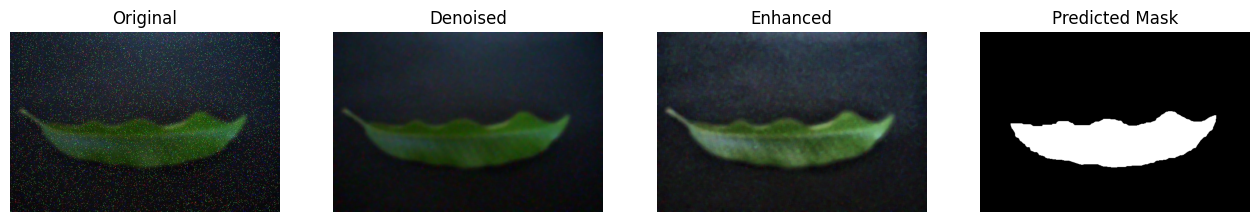

In [39]:
img_path, gt_path, class_name = pairs[0]

original, denoised, enhanced, pred_mask = segment_leaf(img_path)

gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]))
_, gt_mask = cv2.threshold(gt_mask, 5, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
plt.title("Denoised")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
plt.title("Enhanced")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [40]:
def calculate_iou(pred_mask, gt_mask):
    pred = pred_mask > 0
    gt = gt_mask > 0

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    if union == 0:
        return 0

    return intersection / union

Class: Mango_(P0)
Image: 0001_0064.JPG
GT: 0001_0064.JPG
IoU normal: 0.9543506563957904
IoU inverted: 0.002030971264897279


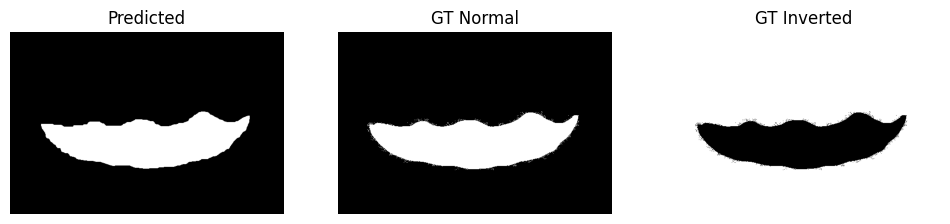

In [43]:
img_path, gt_path, class_name = pairs[0]

original, denoised, enhanced, pred_mask = segment_leaf(img_path)

gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]))
_, gt_mask = cv2.threshold(gt_mask, 5, 255, cv2.THRESH_BINARY)

iou_normal = calculate_iou(pred_mask, gt_mask)
iou_inverted = calculate_iou(pred_mask, 255 - gt_mask)

print("Class:", class_name)
print("Image:", os.path.basename(img_path))
print("GT:", os.path.basename(gt_path))
print("IoU normal:", iou_normal)
print("IoU inverted:", iou_inverted)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gt_mask, cmap="gray")
plt.title("GT Normal")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(255 - gt_mask, cmap="gray")
plt.title("GT Inverted")
plt.axis("off")

plt.show()

In [44]:
results = []

SAVE_DIR = "/content/segmented_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

for img_path, gt_path, class_name in pairs:

    original, denoised, enhanced, pred_mask = segment_leaf(img_path)

    gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

    if pred_mask is None or gt_mask is None:
        continue

    gt_mask = cv2.resize(
        gt_mask,
        (pred_mask.shape[1], pred_mask.shape[0])
    )

    # IMPORTANT FIX
    _, gt_mask = cv2.threshold(
        gt_mask,
        5,
        255,
        cv2.THRESH_BINARY
    )

    iou = calculate_iou(pred_mask, gt_mask)

    # Save masks
    class_save_dir = os.path.join(SAVE_DIR, class_name)
    os.makedirs(class_save_dir, exist_ok=True)

    save_name = (
        os.path.splitext(os.path.basename(img_path))[0]
        + "_segmented.png"
    )

    save_path = os.path.join(class_save_dir, save_name)

    cv2.imwrite(save_path, pred_mask)

    results.append({
        "class": class_name,
        "image": os.path.basename(img_path),
        "iou": iou
    })

results_df = pd.DataFrame(results)

print("Done.")
print("Processed images:", len(results_df))

results_df.head()

Done.
Processed images: 1971


,class,image,iou
0,Mango_(P0),0001_0064.JPG,0.954351
1,Mango_(P0),0001_0105.JPG,0.952621
2,Mango_(P0),0001_0104.JPG,0.896746
3,Mango_(P0),0001_0009.JPG,0.920363
4,Mango_(P0),0001_0067.JPG,0.901970


In [46]:
average_iou = results_df["iou"].mean()

print("Average IoU / Jaccard Index =", average_iou)

print("\nAverage IoU per class:\n")

class_results = (
    results_df
    .groupby("class")["iou"]
    .mean()
    .sort_values(ascending=False)
)

print(class_results)

Average IoU / Jaccard Index = 0.9288083515783994

Average IoU per class:

class
Jamun_(P5)                 0.966663
Pongamia_Pinnata_(P7)      0.965573
Jatropha_(P6)              0.964635
Lemon_(P10)                0.957108
Basil_(P8)                 0.949659
Alstonia_Scholaris_(P2)    0.940185
Chinar_(P11)               0.935414
Mango_(P0)                 0.930029
Arjun_(P1)                 0.900613
Pomegranate_(P9)           0.820600
Name: iou, dtype: float64


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [96]:
def extract_features(binary_mask, original_image=None):

    features = {}

    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        return None

    contour = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = w / h
    extent = area / (w * h)

    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)

    solidity = area / hull_area if hull_area != 0 else 0

    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter != 0 else 0

    equivalent_diameter = np.sqrt(4 * area / np.pi)

    if len(contour) >= 5:
        ellipse = cv2.fitEllipse(contour)
        major_axis = max(ellipse[1])
        minor_axis = min(ellipse[1])
        eccentricity = np.sqrt(1 - (minor_axis / major_axis) ** 2) if major_axis != 0 else 0
    else:
        major_axis = 0
        minor_axis = 0
        eccentricity = 0

    convexity = hull_area / area if area != 0 else 0

    moments = cv2.moments(contour)
    hu_moments = cv2.HuMoments(moments).flatten()

    hu_moments = [
        -np.sign(h) * np.log10(abs(h) + 1e-10)
        for h in hu_moments
    ]

    contour_points = contour[:, 0, :]
    complex_contour = contour_points[:, 0] + 1j * contour_points[:, 1]

    fourier_result = np.fft.fft(complex_contour)
    fourier_magnitude = np.abs(fourier_result)

    if fourier_magnitude[0] != 0:
        fourier_magnitude = fourier_magnitude / fourier_magnitude[0]

    fourier_features = fourier_magnitude[1:31]

    if len(fourier_features) < 30:
        fourier_features = np.pad(fourier_features, (0, 30 - len(fourier_features)))

    features["area"] = area
    features["perimeter"] = perimeter
    features["aspect_ratio"] = aspect_ratio
    features["extent"] = extent
    features["solidity"] = solidity
    features["circularity"] = circularity
    features["equivalent_diameter"] = equivalent_diameter
    features["major_axis"] = major_axis
    features["minor_axis"] = minor_axis
    features["eccentricity"] = eccentricity
    features["convexity"] = convexity

    for i, h in enumerate(hu_moments):
        features[f"hu_{i+1}"] = h

    for i, fd in enumerate(fourier_features):
        features[f"fourier_{i+1}"] = fd

    # Color features from original image
    if original_image is not None:
        mask_bool = binary_mask > 0

        hsv = cv2.cvtColor(original_image, cv2.COLOR_RGB2HSV)

        for i, channel in enumerate(["h", "s", "v"]):
            values = hsv[:, :, i][mask_bool]

            features[f"{channel}_mean"] = np.mean(values)
            features[f"{channel}_std"] = np.std(values)
            features[f"{channel}_min"] = np.min(values)
            features[f"{channel}_max"] = np.max(values)

    return features

In [97]:
feature_rows = []

for img_path, gt_path, class_name in pairs:

    original, denoised, enhanced, pred_mask = segment_leaf(img_path)

    if pred_mask is None:
        continue

    features = extract_features(pred_mask, original)

    if features is None:
        continue

    features["class"] = class_name
    feature_rows.append(features)

features_df = pd.DataFrame(feature_rows)

print("Feature table shape:", features_df.shape)
features_df.head()

Feature table shape: (1971, 61)


,area,perimeter,aspect_ratio,extent,solidity,circularity,equivalent_diameter,major_axis,minor_axis,eccentricity,convexity,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,hu_7,fourier_1,fourier_2,fourier_3,fourier_4,fourier_5,fourier_6,fourier_7,fourier_8,fourier_9,fourier_10,fourier_11,fourier_12,fourier_13,fourier_14,fourier_15,fourier_16,fourier_17,fourier_18,fourier_19,fourier_20,fourier_21,fourier_22,fourier_23,fourier_24,fourier_25,fourier_26,fourier_27,fourier_28,fourier_29,fourier_30,h_mean,h_std,h_min,h_max,s_mean,s_std,s_min,s_max,v_mean,v_std,v_min,v_max,class
0,35181.5,1088.908723,3.656000,0.615869,0.858651,0.372856,211.647058,487.581940,108.598000,0.974881,1.164618,0.415674,0.929574,2.536095,3.375542,7.882508,-4.354965,-6.331437,0.183534,0.021917,0.015073,0.006676,0.005744,0.005698,0.006223,0.007631,0.001696,0.001422,0.000975,0.001161,0.000939,0.000928,0.000664,0.000483,0.000847,0.000555,0.000774,0.000216,0.000345,0.000331,0.000843,0.000413,0.000414,0.000306,0.000245,0.000075,0.000091,0.000133,53.324390,10.656627,0,128,166.292907,53.623122,8,255,72.295599,25.197009,4,255,Mango_(P0)
1,54902.0,1105.636645,2.185930,0.634229,0.971502,0.564382,264.392506,447.447327,164.918076,0.929598,1.029334,0.611311,1.479015,3.093519,3.693349,7.108604,4.516009,-7.589642,0.144501,0.021623,0.013071,0.007566,0.002646,0.004281,0.001694,0.003847,0.001359,0.002869,0.000554,0.001605,0.000780,0.001824,0.000445,0.001091,0.000431,0.000698,0.000090,0.000576,0.000309,0.000100,0.000587,0.000398,0.000216,0.000265,0.000558,0.000176,0.000163,0.000098,46.591620,7.025287,0,176,188.942777,47.287362,8,255,74.371645,23.951864,5,255,Mango_(P0)
2,49517.5,1158.766588,1.869955,0.532498,0.944045,0.463422,251.092889,447.839203,143.788605,0.947055,1.059272,0.558341,1.297229,3.583653,4.039021,7.861169,4.745941,8.440832,0.161247,0.015993,0.008849,0.003845,0.005703,0.002627,0.004137,0.001644,0.001708,0.002668,0.001268,0.002230,0.001171,0.001263,0.001309,0.000295,0.001670,0.001283,0.001335,0.000157,0.000960,0.000485,0.000402,0.000870,0.001058,0.000372,0.000592,0.000355,0.000113,0.000299,56.673681,15.051348,0,179,163.613233,56.721074,0,255,50.328138,25.008501,1,255,Mango_(P0)
3,47484.5,1482.766588,3.564935,0.561641,0.756123,0.271404,245.884410,566.599609,130.563919,0.973088,1.322537,0.410793,0.914464,3.381962,4.382718,-8.329136,-4.940727,-8.521472,0.228922,0.007209,0.031647,0.011451,0.011452,0.004241,0.001564,0.007697,0.006506,0.001181,0.003886,0.005198,0.000192,0.003511,0.001394,0.002242,0.003377,0.002903,0.002755,0.000951,0.001055,0.000921,0.001685,0.000945,0.000560,0.002142,0.001318,0.000870,0.001769,0.000558,70.333887,23.616832,0,179,141.638566,60.187598,0,255,48.070954,26.235816,1,255,Mango_(P0)
4,24031.5,938.859953,3.050420,0.556323,0.800117,0.342601,174.922429,354.595795,98.519569,0.960628,1.249818,0.471078,1.071652,2.585448,3.191441,6.195235,4.128614,-6.272206,0.130080,0.013901,0.015737,0.006149,0.007356,0.006163,0.004112,0.002448,0.001537,0.000700,0.003194,0.001225,0.002586,0.001798,0.002051,0.001840,0.001543,0.001421,0.000549,0.000478,0.000303,0.000488,0.000611,0.001042,0.000639,0.000766,0.000821,0.000731,0.000877,0.000173,64.568270,23.530424,0,179,136.482325,63.868700,0,255,48.078630,24.759619,0,255,Mango_(P0)


In [98]:
print(features_df.info())

features_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1971 entries, 0 to 1970
Data columns (total 61 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   area                 1971 non-null   float64
 1   perimeter            1971 non-null   float64
 2   aspect_ratio         1971 non-null   float64
 3   extent               1971 non-null   float64
 4   solidity             1971 non-null   float64
 5   circularity          1971 non-null   float64
 6   equivalent_diameter  1971 non-null   float64
 7   major_axis           1971 non-null   float64
 8   minor_axis           1971 non-null   float64
 9   eccentricity         1971 non-null   float64
 10  convexity            1971 non-null   float64
 11  hu_1                 1971 non-null   float64
 12  hu_2                 1971 non-null   float64
 13  hu_3                 1971 non-null   float64
 14  hu_4                 1971 non-null   float64
 15  hu_5                 1971 non-null   f

,area,perimeter,aspect_ratio,extent,solidity,circularity,equivalent_diameter,major_axis,minor_axis,eccentricity,convexity,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,hu_7,fourier_1,fourier_2,fourier_3,fourier_4,fourier_5,fourier_6,fourier_7,fourier_8,fourier_9,fourier_10,fourier_11,fourier_12,fourier_13,fourier_14,fourier_15,fourier_16,fourier_17,fourier_18,fourier_19,fourier_20,fourier_21,fourier_22,fourier_23,fourier_24,fourier_25,fourier_26,fourier_27,fourier_28,fourier_29,fourier_30,h_mean,h_std,h_min,h_max,s_mean,s_std,s_min,s_max,v_mean,v_std,v_min,v_max
count,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1.971000e+03,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.0,1971.000000,1971.000000,1971.000000,1971.000000
mean,49641.523338,1064.839991,1.827099,0.629068,0.917417,0.566770,236.575991,346.124426,179.697102,0.816099,1.102279,0.667289,1.974964,3.738497,4.668507,5.280570,2.736064,-0.024471,0.091231,0.016353,0.014607,0.008454,0.007237,0.004505,0.003987,0.002972,0.002755,0.002168,0.001965,0.001579,0.001504,0.001276,0.001193,0.001014,0.000986,0.000891,0.000790,0.000711,7.165974e-04,0.000662,0.000598,0.000561,0.000552,0.000511,0.000480,0.000476,0.000455,0.000408,52.780767,11.052947,3.872653,153.423135,157.053251,46.034359,8.886352,255.0,78.811095,24.764734,4.243531,253.825977
std,35226.460924,672.194077,0.660816,0.093522,0.082885,0.155706,85.094212,116.985104,85.085378,0.152079,0.139918,0.094702,0.690246,0.755699,1.022375,6.900485,5.343739,9.024694,0.051363,0.012896,0.012042,0.010326,0.007864,0.005959,0.004188,0.003816,0.003352,0.003100,0.002358,0.002214,0.001989,0.001717,0.001637,0.001360,0.001432,0.001502,0.001073,0.001057,1.274504e-03,0.001128,0.000933,0.000845,0.000904,0.000828,0.000741,0.000772,0.000897,0.000663,7.989161,7.670213,6.648882,34.797770,21.436082,10.030377,11.899847,0.0,24.764322,1.848979,3.777243,4.571447
min,2186.500000,202.852812,0.422492,0.231993,0.344529,0.015466,52.763039,71.936920,31.459124,0.110200,1.013108,0.271473,0.618319,1.401544,1.744382,-10.000000,-9.998953,-10.000000,0.002339,0.000129,0.000414,0.000077,0.000095,0.000099,0.000025,0.000013,0.000050,0.000012,0.000004,0.000023,0.000026,0.000008,0.000016,0.000013,0.000009,0.000008,0.000006,0.000018,8.594915e-07,0.000006,0.000008,0.000007,0.000010,0.000006,0.000005,0.000002,0.000007,0.000005,32.180446,2.814553,0.000000,60.000000,102.632079,24.767333,0.000000,255.0,21.249973,21.450898,0.000000,199.000000
25%,23390.500000,711.763017,1.342924,0.576458,0.910389,0.469795,172.573689,264.633331,111.841324,0.764785,1.036931,0.605726,1.465500,3.229678,3.998796,6.289510,3.277143,-9.257510,0.052322,0.007178,0.007304,0.002660,0.002903,0.001562,0.001601,0.001044,0.001073,0.000744,0.000704,0.000556,0.000547,0.000465,0.000437,0.000378,0.000364,0.000313,0.000317,0.000274,2.685599e-04,0.000254,0.000232,0.000215,0.000210,0.000200,0.000192,0.000188,0.000168,0.000162,48.338170,6.578367,0.000000,117.000000,142.117350,38.625741,0.000000,255.0,61.272691,23.528784,1.000000,255.000000
50%,44482.000000,1025.394004,1.691489,0.642087,0.947579,0.597561,237.983700,341.982147,159.736969,0.864462,1.055321,0.694707,1.863503,3.645100,4.615309,8.218141,5.108893,-5.328386,0.081711,0.013027,0.012092,0.005115,0.005040,0.002866,0.002900,0.001898,0.001868,0.001339,0.001298,0.000980,0.000987,0.000822,0.000792,0.000661,0.000641,0.000552,0.000524,0.000472,4.617731e-04,0.000426,0.000399,0.000375,0.000352,0.000342,0.000322,0.000325,0.000292,0.000271,51.4818

In [77]:
features_df["class"].value_counts()

,count
class,
Pongamia_Pinnata_(P7),319
Pomegranate_(P9),286
Jamun_(P5),267
Arjun_(P1),214
Alstonia_Scholaris_(P2),174
Mango_(P0),170
Lemon_(P10),159
Basil_(P8),148
Jatropha_(P6),131


In [99]:
X = features_df.drop("class", axis=1)
y = features_df["class"]

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (1971, 60)
Labels shape: (1971,)


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    train_size=0.80,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1576, 60)
Testing data: (395, 60)


In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.8126582278481013


In [103]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [1, 0.1, 0.01, 0.001, 0.0001],
    "kernel": ["linear", "rbf", "poly"]
}

svm_grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    verbose=1,
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(svm_grid.best_params_)

print("\nBest Estimator:")
print(svm_grid.best_estimator_)

best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("\nTuned SVM Accuracy:", svm_accuracy)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best Estimator:
SVC(C=10, gamma=0.01)

Tuned SVM Accuracy: 0.8860759493670886


In [104]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8354430379746836


In [105]:
model_results = pd.DataFrame({
    "Model": ["KNN", "Tuned SVM", "Random Forest"],
    "Accuracy": [knn_accuracy, svm_accuracy, rf_accuracy]
})

model_results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Tuned SVM,0.886076
2,Random Forest,0.835443
0,KNN,0.812658


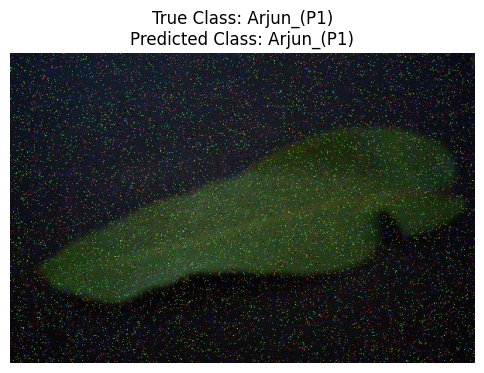

In [109]:
best_model = best_svm

import random

img_path, gt_path, true_class = random.choice(pairs)

original, denoised, enhanced, pred_mask = segment_leaf(img_path)

#  include original image
features = extract_features(pred_mask, original)

sample_df = pd.DataFrame([features])


# reorder columns exactly like training data
sample_df = sample_df[X.columns]

# Scale
sample_scaled = scaler.transform(sample_df)

# Predict
prediction = best_model.predict(sample_scaled)[0]

plt.figure(figsize=(6,6))

plt.imshow(original)

plt.title(
    f"True Class: {true_class}\n"
    f"Predicted Class: {prediction}"
)

plt.axis("off")

plt.show()